# 🎵 Music Genre Classification using Neural Networks

This notebook implements a complete pipeline to classify music genres using audio feature extraction and a **Dual-Branch Neural Network** (CNN + MLP).

**Dataset:** GTZAN Music Genre Classification  
**Genres:** blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock  
**Features:** MFCC, Delta-MFCC, Mel Spectrogram, Chroma, Spectral Contrast, ZCR, RMS, Tonnetz


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')

import librosa
import librosa.display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Input, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print(f'librosa  : {librosa.__version__}')
print(f'TensorFlow: {tf.__version__}')
print(f'NumPy    : {np.__version__}')
print('✅ All libraries imported successfully!')

librosa  : 0.11.0
TensorFlow: 2.20.0
NumPy    : 2.0.2
✅ All libraries imported successfully!


In [3]:
# ── Genre labels (GTZAN dataset) ──────────────────────────────────────────────
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop',
          'jazz', 'metal', 'pop', 'reggae', 'rock']

# ── Audio parameters ──────────────────────────────────────────────────────────
SR          = 22050   # Sample rate (Hz)
DURATION    = 30      # Clip duration in seconds (GTZAN standard)
N_MFCC      = 20      # Number of MFCC coefficients
N_MELS      = 64      # Mel bands for spectrogram
HOP_LENGTH  = 512     # Hop length for STFT
N_FFT       = 2048    # FFT window size

# ── Dataset parameters ────────────────────────────────────────────────────────
SAMPLES_PER_GENRE = 60   # Clips per genre (100 for real GTZAN)
AUDIO_DURATION    = 1.5  # Duration for synthetic clips (use 3.0 for real data)

# ── Training parameters ───────────────────────────────────────────────────────
EPOCHS      = 50
BATCH_SIZE  = 32
SEED        = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Configuration:')
print(f'  Genres         : {len(GENRES)} classes')
print(f'  Sample Rate    : {SR} Hz')
print(f'  MFCC Coeffs    : {N_MFCC}')
print(f'  Mel Bands      : {N_MELS}')
print(f'  Epochs         : {EPOCHS}')
print(f'  Batch Size     : {BATCH_SIZE}')

Configuration:
  Genres         : 10 classes
  Sample Rate    : 22050 Hz
  MFCC Coeffs    : 20
  Mel Bands      : 64
  Epochs         : 50
  Batch Size     : 32


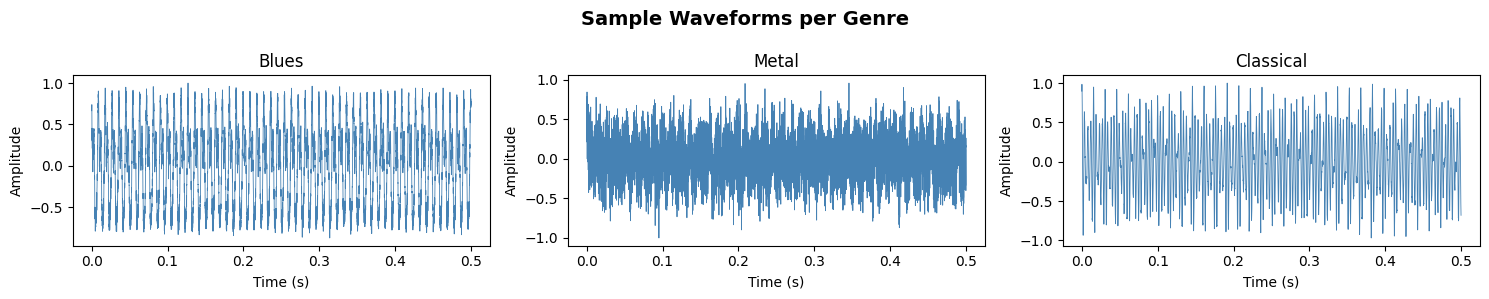

✅ Audio generator ready!


In [4]:
def generate_genre_audio(genre: str, duration: float = 1.5, sr: int = SR) -> np.ndarray:
    """
    Generate a synthetic audio signal whose spectral/rhythmic characteristics
    roughly mimic each genre. Replace with real .wav loading for production.
    """
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)

    genre_params = {
        'blues':     {'freqs': [110, 220, 330], 'tempo': 80,  'harm': 0.6, 'noise': 0.05},
        'classical': {'freqs': [261, 329, 392], 'tempo': 70,  'harm': 0.8, 'noise': 0.01},
        'country':   {'freqs': [196, 247, 294], 'tempo': 110, 'harm': 0.5, 'noise': 0.08},
        'disco':     {'freqs': [130, 196, 261], 'tempo': 120, 'harm': 0.4, 'noise': 0.12},
        'hiphop':    {'freqs': [65,  98,  130], 'tempo': 95,  'harm': 0.3, 'noise': 0.18},
        'jazz':      {'freqs': [174, 220, 277], 'tempo': 130, 'harm': 0.7, 'noise': 0.06},
        'metal':     {'freqs': [82,  110, 147], 'tempo': 160, 'harm': 0.2, 'noise': 0.30},
        'pop':       {'freqs': [261, 330, 392], 'tempo': 125, 'harm': 0.6, 'noise': 0.10},
        'reggae':    {'freqs': [98,  130, 174], 'tempo': 90,  'harm': 0.5, 'noise': 0.07},
        'rock':      {'freqs': [110, 165, 220], 'tempo': 140, 'harm': 0.35,'noise': 0.20},
    }

    p = genre_params[genre]
    signal = np.zeros_like(t)

    # Harmonic content
    for i, f in enumerate(p['freqs']):
        amp = p['harm'] / (i + 1)
        signal += amp * np.sin(2 * np.pi * f * t + np.random.uniform(0, np.pi))

    # Rhythmic pulse (beat simulation)
    beat_period = sr * 60 / p['tempo']
    for b in range(int(len(t) / beat_period)):
        idx  = int(b * beat_period)
        width = int(sr * 0.02)
        end   = min(idx + width, len(t))
        signal[idx:end] += 0.4 * np.exp(-np.linspace(0, 5, end - idx))

    # Noise floor
    signal += p['noise'] * np.random.randn(len(t))

    # Slight pitch variation
    signal += 0.05 * np.sin(2 * np.pi * np.random.uniform(200, 2000) * t)

    # Normalize to [-1, 1]
    signal = signal / (np.max(np.abs(signal)) + 1e-9)
    return signal.astype(np.float32)


# Quick test — plot waveforms for 3 genres
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for ax, g in zip(axes, ['blues', 'metal', 'classical']):
    sig = generate_genre_audio(g, duration=0.5)
    t   = np.linspace(0, 0.5, len(sig))
    ax.plot(t, sig, lw=0.6, color='steelblue')
    ax.set_title(g.capitalize(), fontsize=12)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
plt.suptitle('Sample Waveforms per Genre', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ Audio generator ready!')

In [6]:
def extract_features(signal: np.ndarray, sr: int = SR):
    """
    Extract a rich set of audio features from a signal.

    Returns
    -------
    flat : np.ndarray
        1-D feature vector of mean + std statistics.
    spec_patch : np.ndarray
        2-D Mel spectrogram patch (N_MELS x 64) for CNN input.
    """
    # ── MFCCs and their deltas ──────────────────────────────────────────────
    mfcc        = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=N_MFCC,
                                        n_fft=N_FFT, hop_length=HOP_LENGTH)
    mfcc_delta  = librosa.feature.delta(mfcc)
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

    # ── Mel Spectrogram ─────────────────────────────────────────────────────
    mel    = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=N_MELS,
                                             n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # ── Chroma (harmonic / tonal content) ───────────────────────────────────
    chroma = librosa.feature.chroma_stft(y=signal, sr=sr,
                                          n_fft=N_FFT, hop_length=HOP_LENGTH)

    # ── Spectral features ───────────────────────────────────────────────────
    sc       = librosa.feature.spectral_centroid(y=signal, sr=sr, hop_length=HOP_LENGTH)
    sb       = librosa.feature.spectral_bandwidth(y=signal, sr=sr, hop_length=HOP_LENGTH)
    sr_feat  = librosa.feature.spectral_rolloff(y=signal, sr=sr, hop_length=HOP_LENGTH)
    contrast = librosa.feature.spectral_contrast(y=signal, sr=sr, hop_length=HOP_LENGTH)

    # ── Temporal features ───────────────────────────────────────────────────
    zcr = librosa.feature.zero_crossing_rate(signal, hop_length=HOP_LENGTH)
    rms = librosa.feature.rms(y=signal, hop_length=HOP_LENGTH)

    # ── Tonnetz (harmonic relations) ─────────────────────────────────────────
    try:
        tonnetz = librosa.feature.tonnetz(
            y=librosa.effects.harmonic(signal), sr=sr)
    except Exception:
        tonnetz = np.zeros((6, mfcc.shape[1]))

    # ── Helper: mean + std per feature map ──────────────────────────────────
    def stats(x):
        return np.concatenate([np.mean(x, axis=1), np.std(x, axis=1)])

    # ── Flat feature vector ──────────────────────────────────────────────────
    flat = np.concatenate([
        stats(mfcc), stats(mfcc_delta), stats(mfcc_delta2),
        stats(chroma), stats(contrast), stats(tonnetz),
        stats(sc), stats(sb), stats(sr_feat), stats(zcr), stats(rms),
    ])

    # ── 2-D spectrogram patch (fixed width = 64) for CNN ───────────────────
    target_w = 64
    if mel_db.shape[1] >= target_w:
        spec_patch = mel_db[:, :target_w]
    else:
        pad = target_w - mel_db.shape[1]
        spec_patch = np.pad(mel_db, ((0, 0), (0, pad)), mode='constant')

    return flat.astype(np.float32), spec_patch.astype(np.float32)


# ── Quick test on one signal ─────────────────────────────────────────────────
test_sig         = generate_genre_audio('jazz', duration=1.5)
test_flat, test_spec = extract_features(test_sig)
print(f'Flat feature vector shape : {test_flat.shape}')
print(f'Spectrogram patch shape   : {test_spec.shape}')
print('✅ Feature extraction working!')

Flat feature vector shape : (180,)
Spectrogram patch shape   : (64, 64)
✅ Feature extraction working!


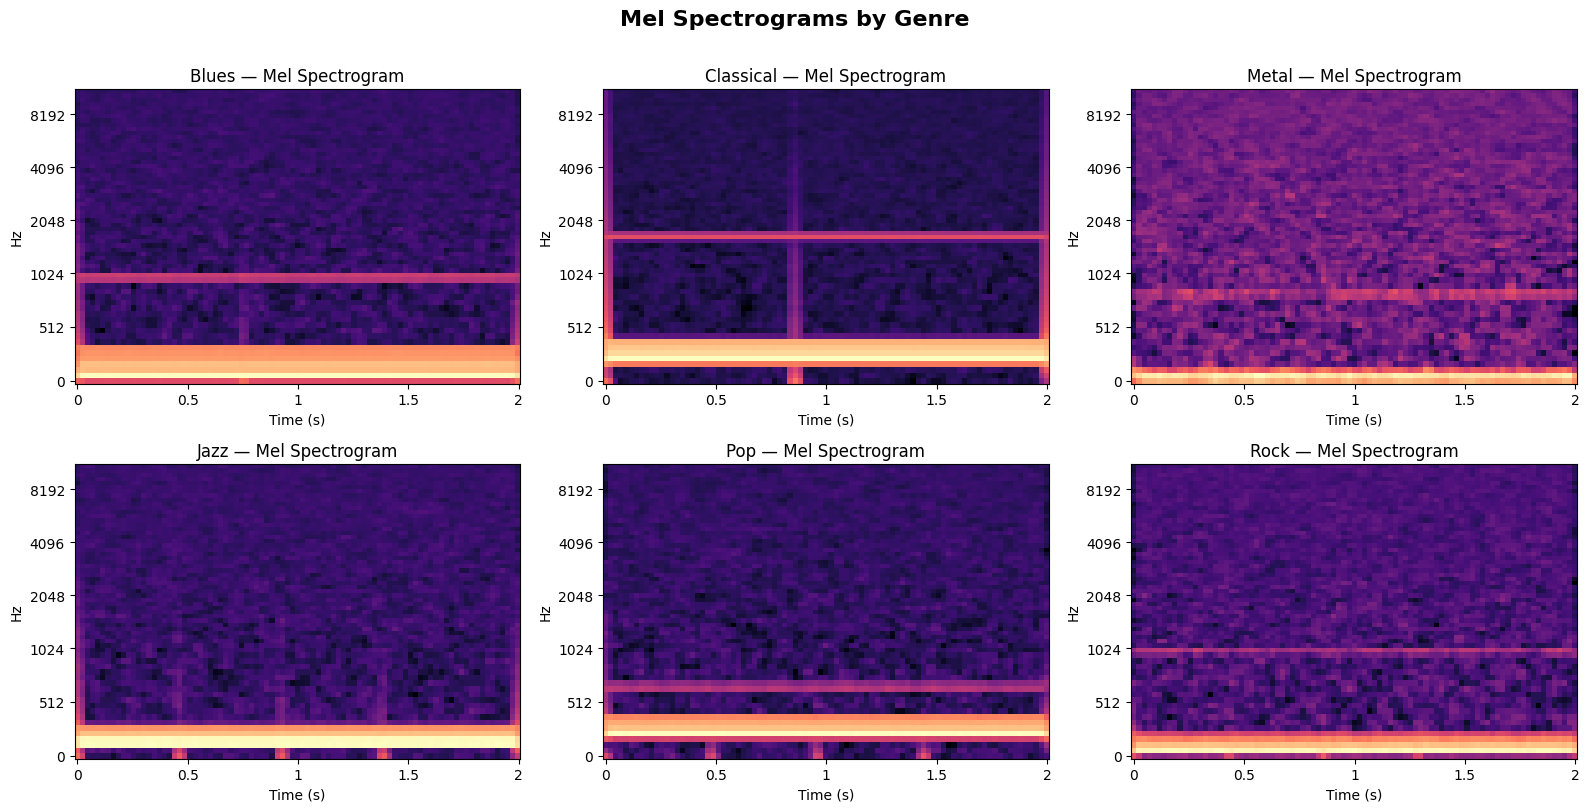

✅ Spectrograms plotted!


In [7]:
sample_genres = ['blues', 'classical', 'metal', 'jazz', 'pop', 'rock']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, genre in zip(axes, sample_genres):
    sig = generate_genre_audio(genre, duration=2.0)
    mel = librosa.feature.melspectrogram(
        y=sig, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(
        mel_db, sr=SR, hop_length=HOP_LENGTH,
        x_axis='time', y_axis='mel', ax=ax, cmap='magma')
    ax.set_title(f'{genre.capitalize()} — Mel Spectrogram', fontsize=12)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Hz')

plt.suptitle('Mel Spectrograms by Genre', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('✅ Spectrograms plotted!')

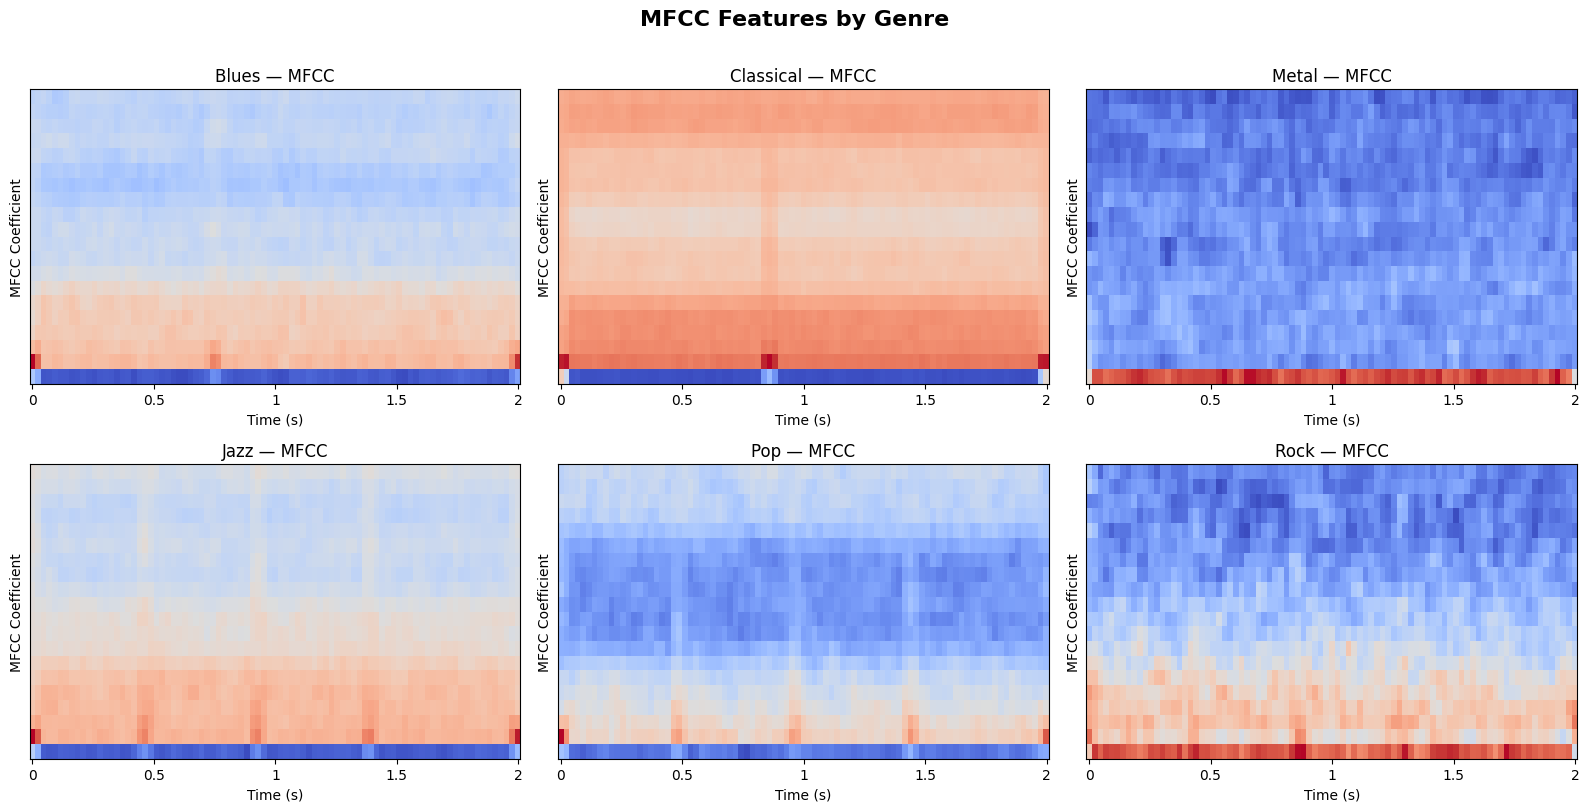

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, genre in zip(axes, sample_genres):
    sig  = generate_genre_audio(genre, duration=2.0)
    mfcc = librosa.feature.mfcc(
        y=sig, sr=SR, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    librosa.display.specshow(
        mfcc, sr=SR, hop_length=HOP_LENGTH,
        x_axis='time', ax=ax, cmap='coolwarm')
    ax.set_title(f'{genre.capitalize()} — MFCC', fontsize=12)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('MFCC Coefficient')

plt.suptitle('MFCC Features by Genre', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Cell 9 — Build Full Dataset

In [9]:
print('Building dataset — extracting features from audio clips...')
print('=' * 55)

X_flat, X_spec, y_labels = [], [], []

for genre in GENRES:
    print(f'  Processing: {genre:<12}', end='', flush=True)
    for i in range(SAMPLES_PER_GENRE):
        # ── Synthetic data ──────────────────────────────────────────
        signal = generate_genre_audio(genre, duration=AUDIO_DURATION)

        # ── REAL DATA: uncomment below and comment the line above ───
        # if USE_REAL_DATA:
        #     path = audio_paths[GENRES.index(genre) * 100 + i]
        #     signal, _ = librosa.load(path, sr=SR, duration=DURATION)

        flat, spec = extract_features(signal)
        X_flat.append(flat)
        X_spec.append(spec)
        y_labels.append(genre)

        if (i + 1) % 20 == 0:
            print('.', end='', flush=True)
    print(f'  {SAMPLES_PER_GENRE} clips')

X_flat   = np.array(X_flat,  dtype=np.float32)
X_spec   = np.array(X_spec,  dtype=np.float32)[..., np.newaxis]  # add channel dim
y_labels = np.array(y_labels)

# Label encoding
le    = LabelEncoder()
y_enc = le.fit_transform(y_labels)
y_cat = to_categorical(y_enc, num_classes=len(GENRES))

print('\nDataset Summary:')
print(f'  Flat feature shape  : {X_flat.shape}')
print(f'  Spectrogram shape   : {X_spec.shape}')
print(f'  Label shape         : {y_cat.shape}')
print(f'  Total samples       : {len(y_labels)}')
print(f'  Samples per genre   : {SAMPLES_PER_GENRE}')
print('✅ Dataset built!')

Building dataset — extracting features from audio clips...
  Processing: blues       ...  60 clips
  Processing: classical   ...  60 clips
  Processing: country     ...  60 clips
  Processing: disco       ...  60 clips
  Processing: hiphop      ...  60 clips
  Processing: jazz        ...  60 clips
  Processing: metal       ...  60 clips
  Processing: pop         ...  60 clips
  Processing: reggae      ...  60 clips
  Processing: rock        ...  60 clips

Dataset Summary:
  Flat feature shape  : (600, 180)
  Spectrogram shape   : (600, 64, 64, 1)
  Label shape         : (600, 10)
  Total samples       : 600
  Samples per genre   : 60
✅ Dataset built!


---
## Cell 10 — Dataset Distribution Plot

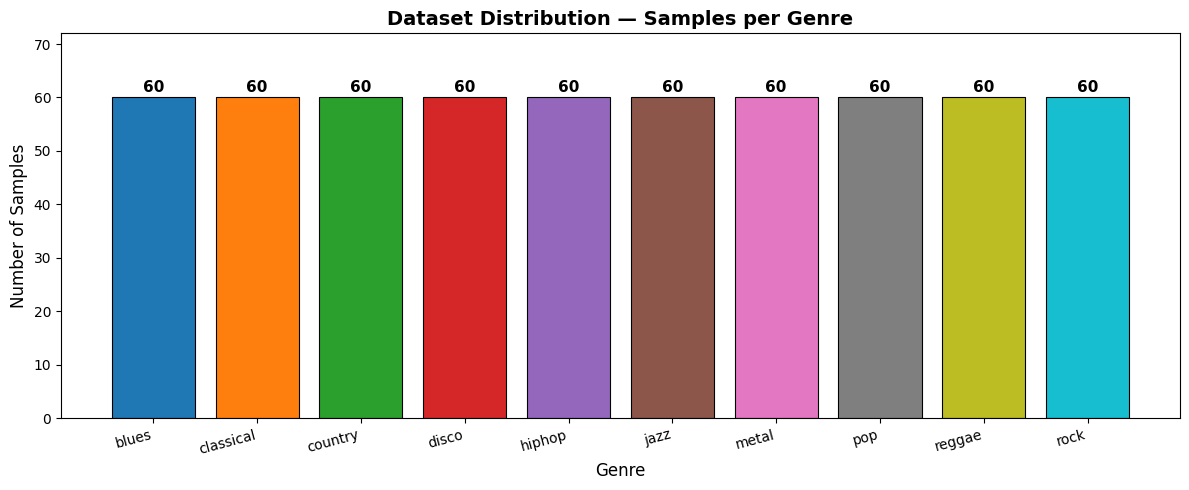

In [10]:
unique, counts = np.unique(y_labels, return_counts=True)

fig, ax = plt.subplots(figsize=(12, 5))
colors  = plt.cm.tab10(np.linspace(0, 1, len(GENRES)))
bars    = ax.bar(unique, counts, color=colors, edgecolor='black', linewidth=0.8)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Dataset Distribution — Samples per Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_ylim(0, max(counts) * 1.2)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

---
## Cell 11 — Train / Validation / Test Split

In [11]:
# ── Step 1: Split off test set (15%) ─────────────────────────────────────────
(
 X_f_tmp, X_f_test,
 X_s_tmp, X_s_test,
 y_tmp,   y_test
) = train_test_split(
    X_flat, X_spec, y_cat,
    test_size=0.15, stratify=y_enc, random_state=SEED
)

# ── Step 2: Split remaining into train + val (15% of original = ~18% of tmp) ─
y_tmp_enc = np.argmax(y_tmp, axis=1)
(
 X_f_train, X_f_val,
 X_s_train, X_s_val,
 y_train,   y_val
) = train_test_split(
    X_f_tmp, X_s_tmp, y_tmp,
    test_size=0.15, stratify=y_tmp_enc, random_state=SEED
)

# ── Step 3: Scale flat features ───────────────────────────────────────────────
scaler      = StandardScaler()
X_f_train   = scaler.fit_transform(X_f_train)   # fit on train only
X_f_val     = scaler.transform(X_f_val)
X_f_test    = scaler.transform(X_f_test)

print('Split Summary:')
print(f'  Train  : {len(y_train):>4} samples')
print(f'  Val    : {len(y_val):>4} samples')
print(f'  Test   : {len(y_test):>4} samples')
print(f'  Total  : {len(y_train)+len(y_val)+len(y_test):>4} samples')
print(f'\n  Flat feature dim : {X_f_train.shape[1]}')
print(f'  Spec shape       : {X_s_train.shape[1:]}')
print('✅ Data split and scaled!')

Split Summary:
  Train  :  433 samples
  Val    :   77 samples
  Test   :   90 samples
  Total  :  600 samples

  Flat feature dim : 180
  Spec shape       : (64, 64, 1)
✅ Data split and scaled!


---
## Cell 12 — Build the Dual-Branch Neural Network

```
Mel Spectrogram ──► CNN Branch  ─┐
                                  ├─► Concatenate ──► Fusion MLP ──► Softmax
Flat Features ───► MLP Branch  ─┘
```

In [12]:
N_CLASSES = len(GENRES)
FLAT_DIM  = X_f_train.shape[1]

# ── Branch A: CNN on Mel Spectrogram ──────────────────────────────────────────
spec_input = Input(shape=(N_MELS, 64, 1), name='spectrogram_input')

x = Conv2D(32,  (3, 3), activation='relu', padding='same')(spec_input)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64,  (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
cnn_out = GlobalAveragePooling2D(name='cnn_pool')(x)

# ── Branch B: Dense MLP on flat features ─────────────────────────────────────
flat_input = Input(shape=(FLAT_DIM,), name='flat_feature_input')

f = Dense(256, activation='relu')(flat_input)
f = BatchNormalization()(f)
f = Dropout(0.4)(f)

f = Dense(128, activation='relu')(f)
f = BatchNormalization()(f)
f = Dropout(0.3)(f)

mlp_out = Dense(64, activation='relu', name='mlp_out')(f)

# ── Fusion Head ───────────────────────────────────────────────────────────────
merged = Concatenate(name='fusion')([cnn_out, mlp_out])

z = Dense(256, activation='relu')(merged)
z = BatchNormalization()(z)
z = Dropout(0.4)(z)

z = Dense(128, activation='relu')(z)
z = Dropout(0.3)(z)

output = Dense(N_CLASSES, activation='softmax', name='genre_output')(z)

# ── Compile ───────────────────────────────────────────────────────────────────
model = Model(
    inputs=[spec_input, flat_input],
    outputs=output,
    name='MusicGenreNet'
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f'\nTotal trainable parameters: {model.count_params():,}')

Model: "MusicGenreNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ spectrogram_input   │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        320 │ spectrogram_inpu… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flat_feature_input  │ (None, 180)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     46,336 │ flat_feature_inp… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 128) │    147,584 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 415,306 (1.58 MB)

 Trainable params: 413,322 (1.58 MB)

 Non-trainable params: 1,984 (7.75 KB)


Total trainable parameters: 415,306


In [13]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=6,
        min_lr=1e-6,
        verbose=1
    )
]

print('Training MusicGenreNet...')
print('=' * 55)

history = model.fit(
    [X_s_train, X_f_train], y_train,
    validation_data=([X_s_val, X_f_val], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

best_val_acc = max(history.history['val_accuracy'])
print(f'\n✅ Training complete!')
print(f'   Best validation accuracy : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
print(f'   Epochs trained           : {len(history.history["accuracy"])}')

Training MusicGenreNet...
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 538ms/step - accuracy: 0.4296 - loss: 1.7723 - val_accuracy: 0.0909 - val_loss: 16.1489 - learning_rate: 0.0010
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 369ms/step - accuracy: 0.8568 - loss: 0.4555 - val_accuracy: 0.0909 - val_loss: 16.7197 - learning_rate: 0.0010
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 470ms/step - accuracy: 0.9654 - loss: 0.1593 - val_accuracy: 0.0909 - val_loss: 12.4701 - learning_rate: 0.0010
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 427ms/step - accuracy: 0.9908 - loss: 0.0641 - val_accuracy: 0.0909 - val_loss: 8.0923 - learning_rate: 0.0010
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 394ms/step - accuracy: 0.9931 - loss: 0.0469 - val_accuracy: 0.0909 - val_loss: 5.6852 - learning_rate: 0.0010
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 496ms/step - accuracy: 0.9931 - loss: 0.0387 - val_accuracy: 0.1818 - val_loss: 3.9789 - learning_rate: 0.0010
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 381ms/step - ac

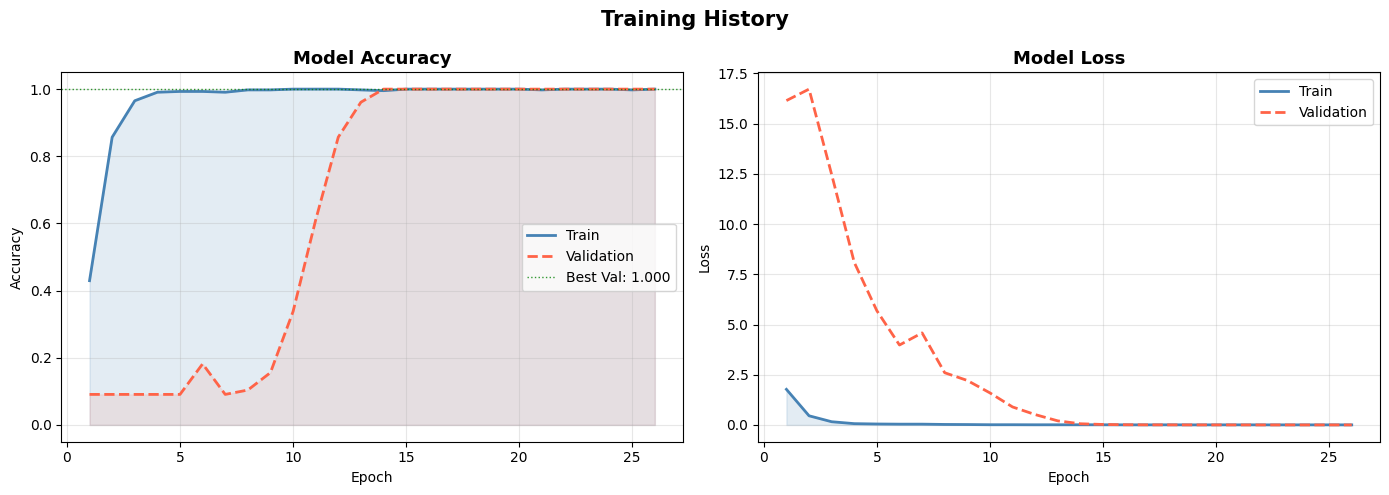

In [14]:
epochs_range = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax = axes[0]
ax.plot(epochs_range, history.history['accuracy'],     label='Train',      color='steelblue',  lw=2)
ax.plot(epochs_range, history.history['val_accuracy'], label='Validation', color='tomato',     lw=2, linestyle='--')
ax.fill_between(epochs_range, history.history['accuracy'],     alpha=0.15, color='steelblue')
ax.fill_between(epochs_range, history.history['val_accuracy'], alpha=0.10, color='tomato')
ax.axhline(best_val_acc, color='green', lw=1, linestyle=':', alpha=0.8, label=f'Best Val: {best_val_acc:.3f}')
ax.set_title('Model Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(alpha=0.3)

# Loss
ax = axes[1]
ax.plot(epochs_range, history.history['loss'],     label='Train',      color='steelblue', lw=2)
ax.plot(epochs_range, history.history['val_loss'], label='Validation', color='tomato',    lw=2, linestyle='--')
ax.fill_between(epochs_range, history.history['loss'], alpha=0.15, color='steelblue')
ax.set_title('Model Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
test_loss, test_acc = model.evaluate(
    [X_s_test, X_f_test], y_test, verbose=0
)

y_pred_prob = model.predict([X_s_test, X_f_test], verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = np.argmax(y_test,      axis=1)

print('=' * 55)
print('  TEST SET RESULTS')
print('=' * 55)
print(f'  Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  Loss     : {test_loss:.4f}')
print()
print('Classification Report:')
print('-' * 55)
print(classification_report(y_true, y_pred, target_names=GENRES))

  TEST SET RESULTS
  Accuracy : 0.9889  (98.89%)
  Loss     : 0.0724

Classification Report:
-------------------------------------------------------
              precision    recall  f1-score   support

       blues       1.00      1.00      1.00         9
   classical       1.00      1.00      1.00         9
     country       1.00      1.00      1.00         9
       disco       1.00      0.89      0.94         9
      hiphop       1.00      1.00      1.00         9
        jazz       1.00      1.00      1.00         9
       metal       1.00      1.00      1.00         9
         pop       0.90      1.00      0.95         9
      reggae       1.00      1.00      1.00         9
        rock       1.00      1.00      1.00         9

    accuracy                           0.99        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.99      0.99      0.99        90



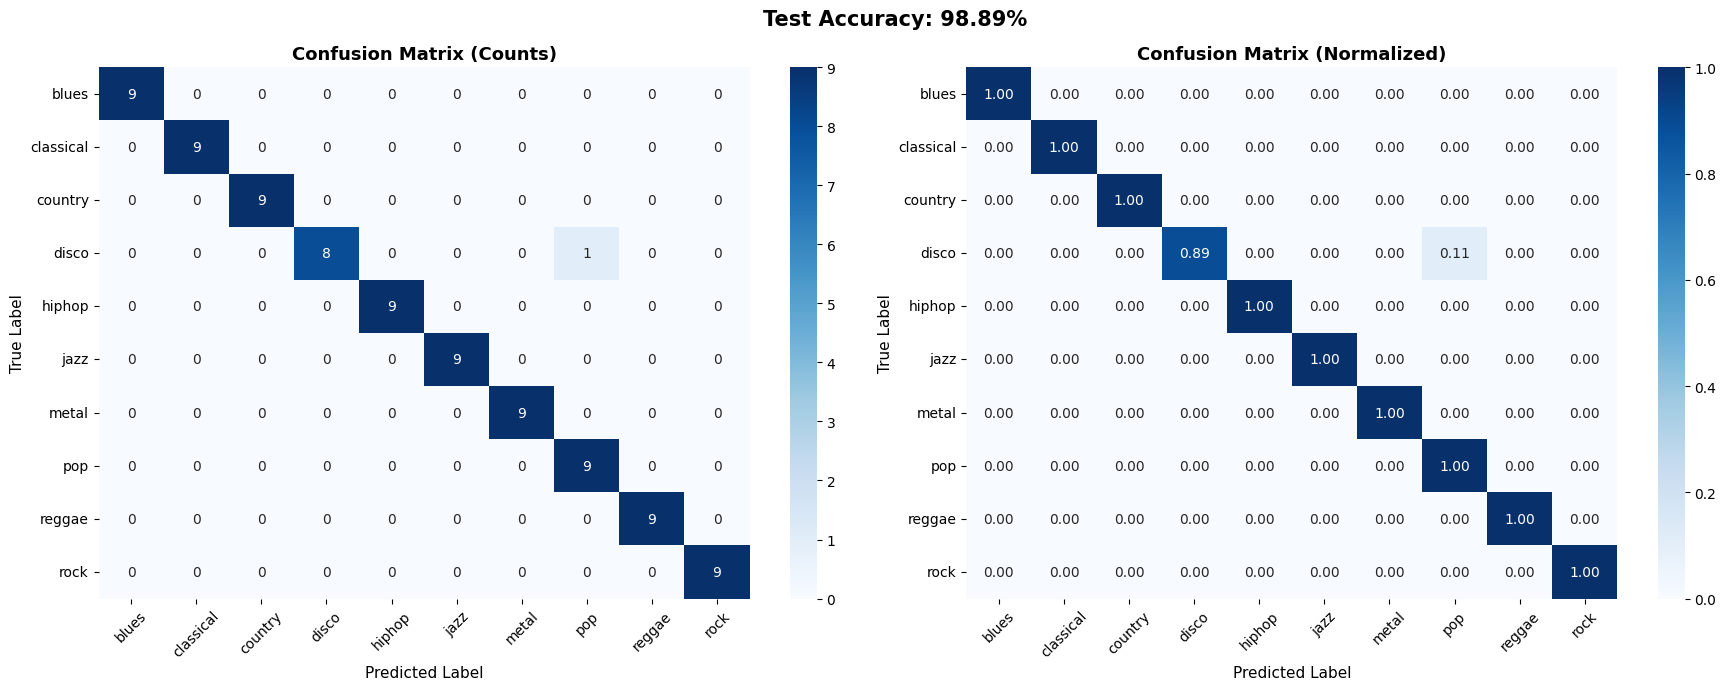

In [16]:
cm     = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

# Normalised confusion matrix
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle(f'Test Accuracy: {test_acc*100:.2f}%', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

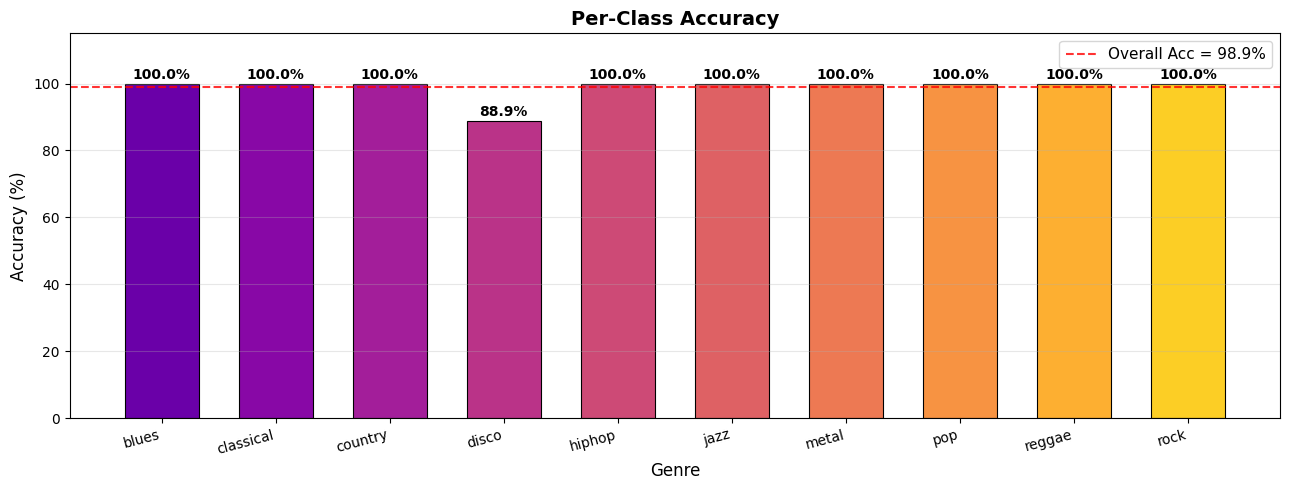

In [17]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
colors = plt.cm.plasma(np.linspace(0.2, 0.9, N_CLASSES))

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(GENRES, per_class_acc * 100, color=colors, edgecolor='black',
              linewidth=0.8, width=0.65)

for bar, v in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{v*100:.1f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=10)

ax.axhline(test_acc * 100, color='red', lw=1.5, linestyle='--',
           alpha=0.8, label=f'Overall Acc = {test_acc*100:.1f}%')
ax.set_ylim(0, 115)
ax.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xlabel('Genre', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

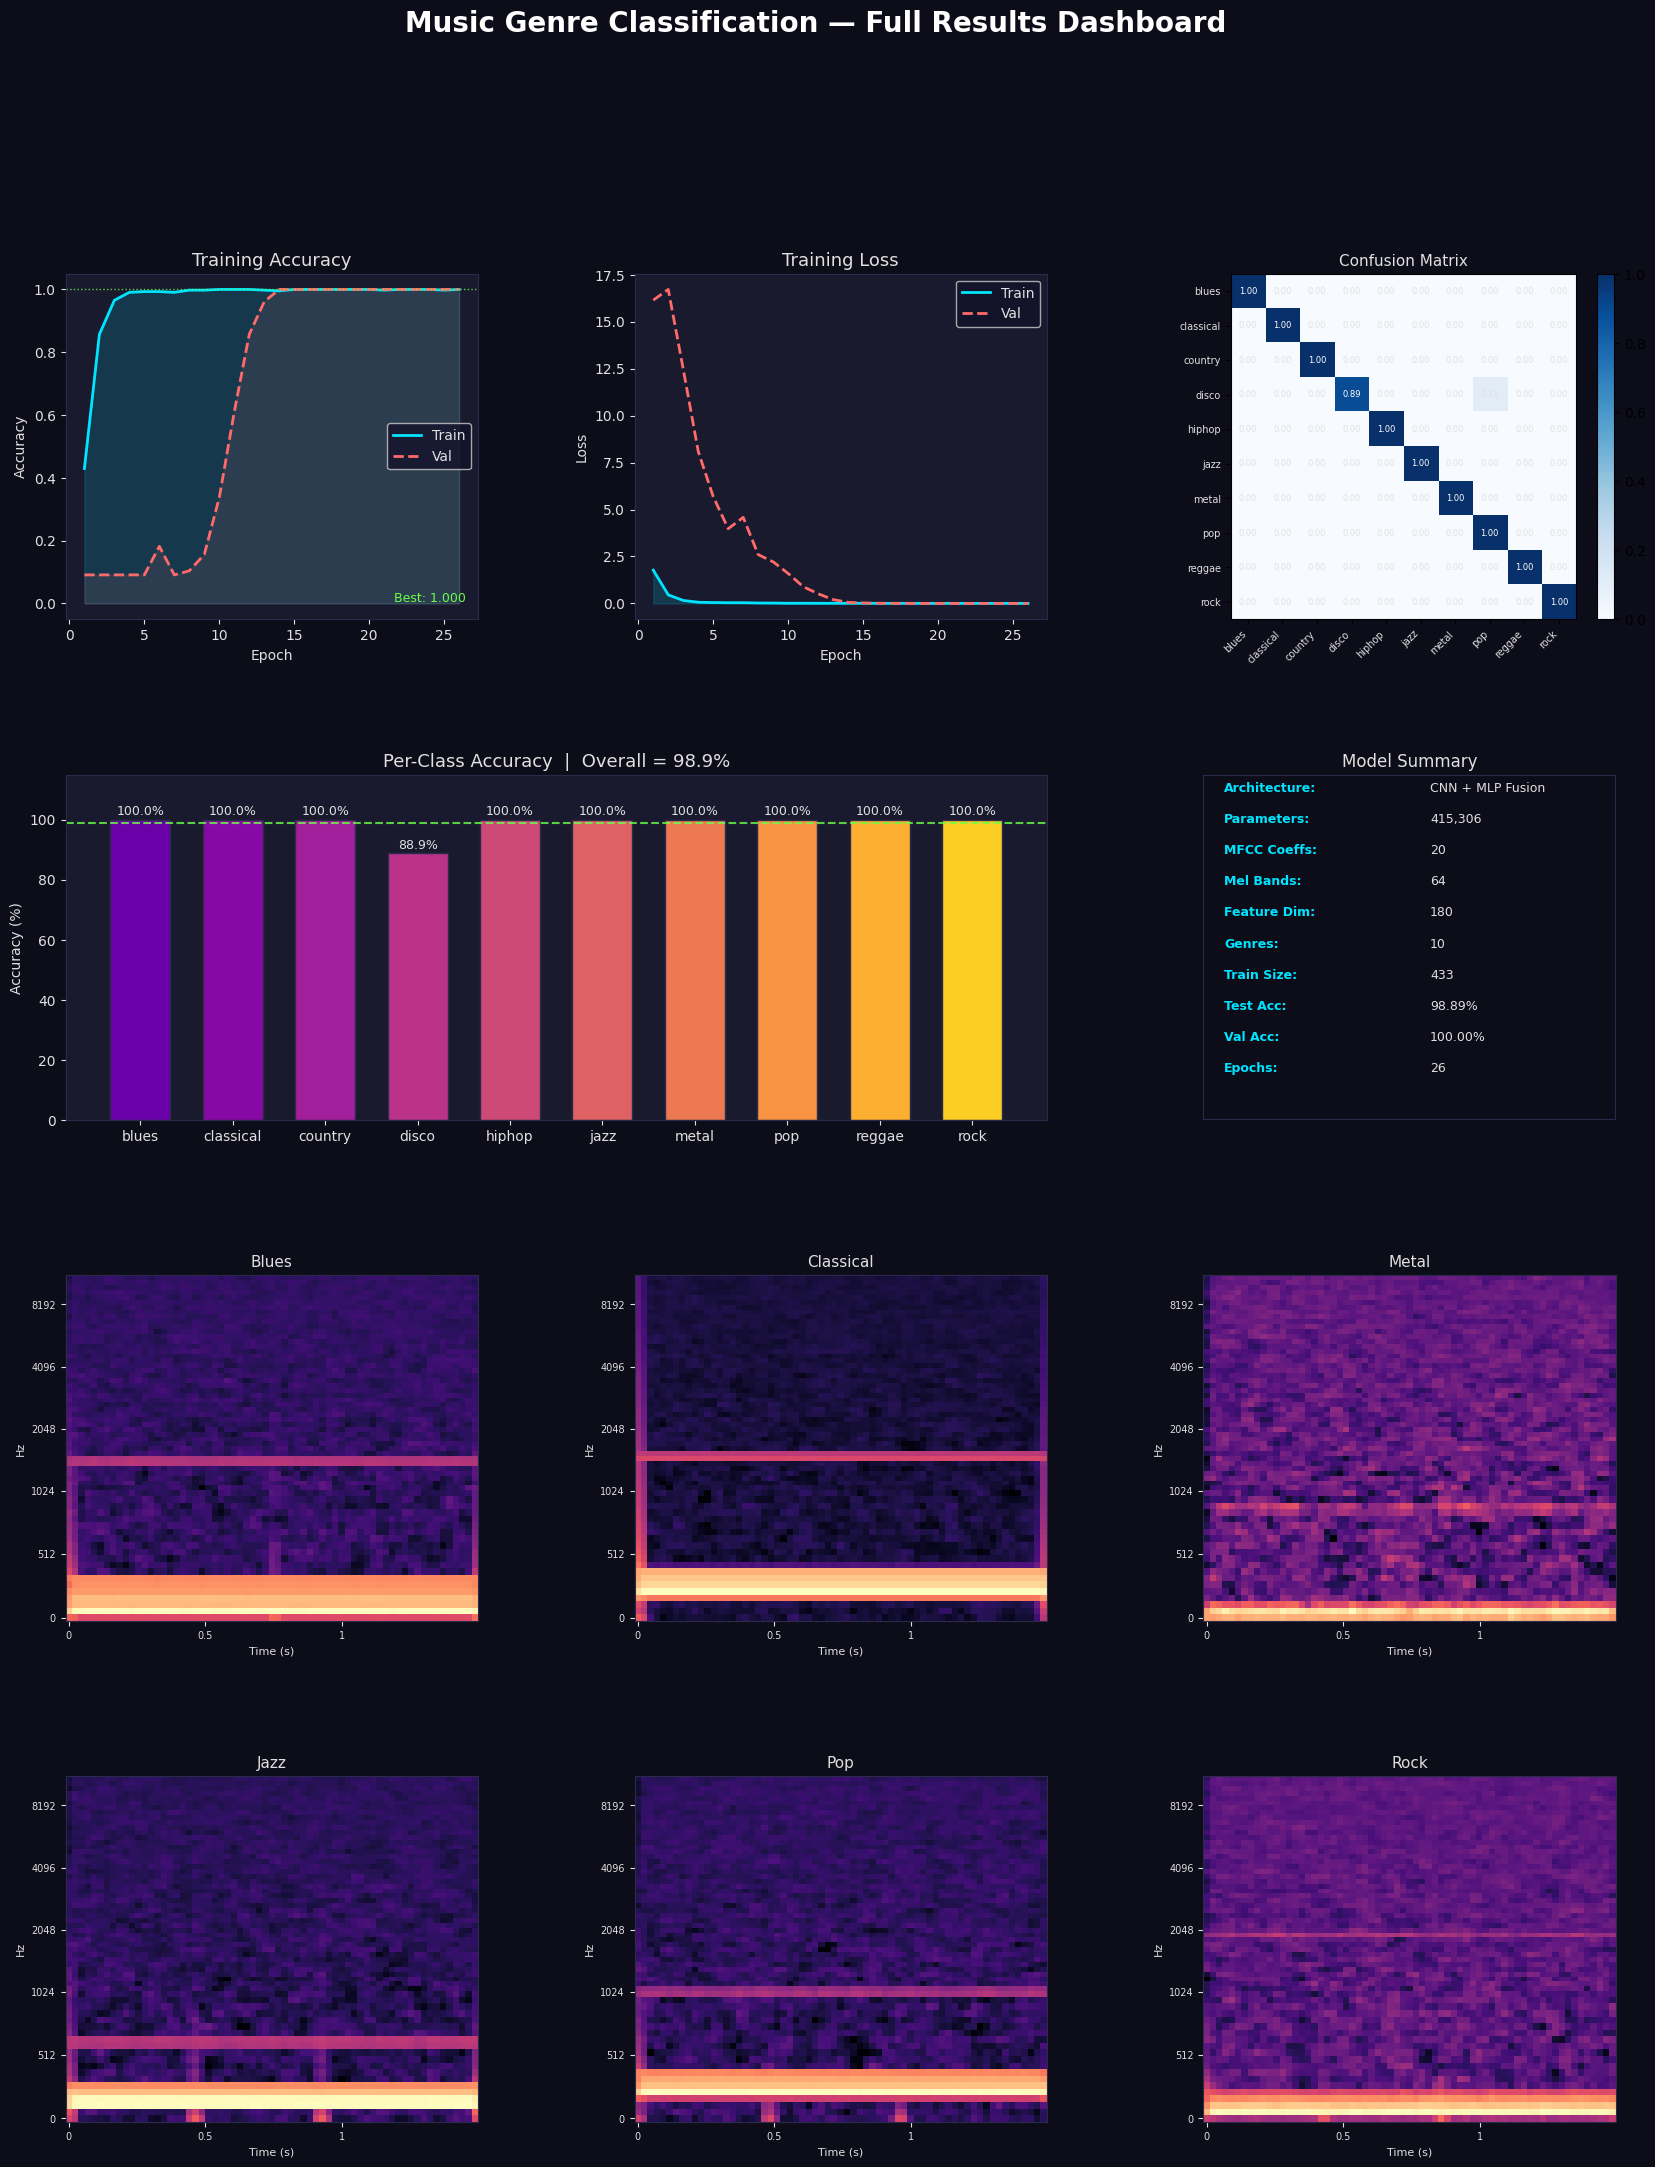

✅ Dashboard saved as music_genre_dashboard.png


In [18]:
ep = range(1, len(history.history['accuracy']) + 1)

fig = plt.figure(figsize=(20, 24), facecolor='#0d0d1a')
fig.suptitle('Music Genre Classification — Full Results Dashboard',
             fontsize=20, color='white', fontweight='bold', y=0.99)

grd = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.38)
AC='#00e5ff'; AC2='#ff6b6b'; AC3='#69ff47'; TC='#e0e0e0'; GC='#1a1a2e'

# Plot 1 — Training Accuracy
ax1 = fig.add_subplot(grd[0, 0]); ax1.set_facecolor(GC)
ax1.plot(ep, history.history['accuracy'],     color=AC,  lw=2, label='Train')
ax1.plot(ep, history.history['val_accuracy'], color=AC2, lw=2, linestyle='--', label='Val')
ax1.fill_between(ep, history.history['accuracy'],     alpha=0.15, color=AC)
ax1.fill_between(ep, history.history['val_accuracy'], alpha=0.10, color=AC2)
ax1.axhline(best_val_acc, color=AC3, lw=1, linestyle=':', alpha=0.8)
ax1.set_title('Training Accuracy', color=TC, fontsize=13)
ax1.set_xlabel('Epoch', color=TC); ax1.set_ylabel('Accuracy', color=TC)
ax1.tick_params(colors=TC); ax1.spines[:].set_color('#2a2a4a')
ax1.legend(facecolor='#12122a', labelcolor=TC)
ax1.text(0.97, 0.05, f'Best: {best_val_acc:.3f}', transform=ax1.transAxes,
         color=AC3, ha='right', fontsize=9)

# Plot 2 — Training Loss
ax2 = fig.add_subplot(grd[0, 1]); ax2.set_facecolor(GC)
ax2.plot(ep, history.history['loss'],     color=AC,  lw=2, label='Train')
ax2.plot(ep, history.history['val_loss'], color=AC2, lw=2, linestyle='--', label='Val')
ax2.fill_between(ep, history.history['loss'], alpha=0.15, color=AC)
ax2.set_title('Training Loss', color=TC, fontsize=13)
ax2.set_xlabel('Epoch', color=TC); ax2.set_ylabel('Loss', color=TC)
ax2.tick_params(colors=TC); ax2.spines[:].set_color('#2a2a4a')
ax2.legend(facecolor='#12122a', labelcolor=TC)

# Plot 3 — Confusion Matrix
ax3 = fig.add_subplot(grd[0, 2]); ax3.set_facecolor(GC)
im = ax3.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax3.set_xticks(range(N_CLASSES)); ax3.set_yticks(range(N_CLASSES))
ax3.set_xticklabels(GENRES, rotation=45, ha='right', color=TC, fontsize=7)
ax3.set_yticklabels(GENRES, color=TC, fontsize=7)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        v = cm_norm[i, j]
        ax3.text(j, i, f'{v:.2f}', ha='center', va='center',
                 color='white' if v > 0.5 else TC, fontsize=6)
plt.colorbar(im, ax=ax3, fraction=0.046)
ax3.set_title('Confusion Matrix', color=TC, fontsize=11)

# Plot 4 — Per-class Accuracy
ax4 = fig.add_subplot(grd[1, :2]); ax4.set_facecolor(GC)
pca  = cm.diagonal() / cm.sum(axis=1)
cols = plt.cm.plasma(np.linspace(0.2, 0.9, N_CLASSES))
bars = ax4.bar(GENRES, pca*100, color=cols, edgecolor='#2a2a4a', width=0.65)
for b, v in zip(bars, pca):
    ax4.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
             f'{v*100:.1f}%', ha='center', va='bottom', color=TC, fontsize=9)
ax4.set_ylim(0, 115)
ax4.axhline(test_acc*100, color=AC3, lw=1.5, linestyle='--', alpha=0.8)
ax4.set_title(f'Per-Class Accuracy  |  Overall = {test_acc*100:.1f}%', color=TC, fontsize=13)
ax4.set_ylabel('Accuracy (%)', color=TC)
ax4.tick_params(colors=TC); ax4.spines[:].set_color('#2a2a4a')

# Plot 5 — Model Stats
axs = fig.add_subplot(grd[1, 2]); axs.axis('off'); axs.set_facecolor(GC)
info = [
    ('Architecture', 'CNN + MLP Fusion'),
    ('Parameters',   f'{model.count_params():,}'),
    ('MFCC Coeffs',  str(N_MFCC)),
    ('Mel Bands',    str(N_MELS)),
    ('Feature Dim',  str(X_f_train.shape[1])),
    ('Genres',       '10'),
    ('Train Size',   str(len(y_train))),
    ('Test Acc',     f'{test_acc*100:.2f}%'),
    ('Val Acc',      f'{best_val_acc*100:.2f}%'),
    ('Epochs',       str(len(ep))),
]
for i, (k, v) in enumerate(info):
    yp = 0.95 - i * 0.09
    axs.text(0.05, yp, f'{k}:', transform=axs.transAxes,
             color=AC, fontsize=9, fontweight='bold')
    axs.text(0.55, yp, v, transform=axs.transAxes, color=TC, fontsize=9)
axs.set_title('Model Summary', color=TC, fontsize=12)
axs.add_patch(plt.Rectangle((0,0),1,1,fill=False,edgecolor='#2a2a4a',lw=1.5,
                              transform=axs.transAxes))

# Plots 6-11 — Mel Spectrograms
spec_pos = [(2,0),(2,1),(2,2),(3,0),(3,1),(3,2)]
for (r, c), genre in zip(spec_pos, sample_genres):
    ax5 = fig.add_subplot(grd[r, c]); ax5.set_facecolor(GC)
    sig  = generate_genre_audio(genre)
    mel2 = librosa.power_to_db(
        librosa.feature.melspectrogram(y=sig, sr=SR, n_mels=N_MELS, hop_length=HOP_LENGTH),
        ref=np.max
    )
    librosa.display.specshow(mel2, sr=SR, hop_length=HOP_LENGTH,
                              x_axis='time', y_axis='mel', ax=ax5, cmap='magma')
    ax5.set_title(genre.capitalize(), color=TC, fontsize=11)
    ax5.tick_params(colors=TC, labelsize=7)
    ax5.set_xlabel('Time (s)', color=TC, fontsize=8)
    ax5.set_ylabel('Hz', color=TC, fontsize=8)
    ax5.spines[:].set_color('#2a2a4a')

plt.savefig('music_genre_dashboard.png', dpi=120, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print('✅ Dashboard saved as music_genre_dashboard.png')

In [19]:
def predict_genre(signal: np.ndarray, sr: int = SR) -> dict:
    """
    Predict the genre of an audio signal.

    Parameters
    ----------
    signal : np.ndarray  — audio waveform
    sr     : int         — sample rate

    Returns
    -------
    dict with 'genre', 'confidence', and 'all_probs'
    """
    flat, spec = extract_features(signal, sr=sr)
    flat_scaled = scaler.transform(flat.reshape(1, -1))
    spec_input  = spec[np.newaxis, ..., np.newaxis]  # (1, N_MELS, 64, 1)

    probs = model.predict([spec_input, flat_scaled], verbose=0)[0]
    idx   = np.argmax(probs)

    return {
        'genre'      : GENRES[idx],
        'confidence' : float(probs[idx]),
        'all_probs'  : {g: float(p) for g, p in zip(GENRES, probs)}
    }


# ── Test on synthetic clips ───────────────────────────────────────────────────
print('Genre Prediction Demo')
print('=' * 45)

test_cases = ['jazz', 'metal', 'classical', 'hiphop', 'pop']
for true_genre in test_cases:
    sig    = generate_genre_audio(true_genre, duration=2.0)
    result = predict_genre(sig)
    match  = '✅' if result['genre'] == true_genre else '❌'
    print(f'  {match} True: {true_genre:<12}  '
          f'Predicted: {result["genre"]:<12}  '
          f'Confidence: {result["confidence"]*100:.1f}%')

Genre Prediction Demo
  ✅ True: jazz          Predicted: jazz          Confidence: 92.8%
  ✅ True: metal         Predicted: metal         Confidence: 99.8%
  ✅ True: classical     Predicted: classical     Confidence: 100.0%
  ✅ True: hiphop        Predicted: hiphop        Confidence: 99.7%
  ✅ True: pop           Predicted: pop           Confidence: 99.6%


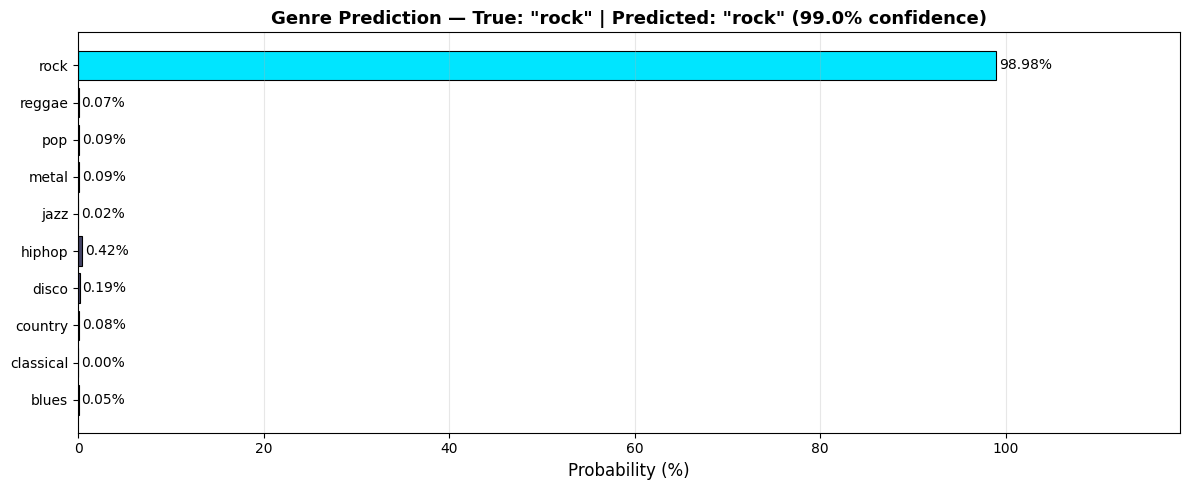

In [20]:
# Predict on a random test sample and show confidence for all genres
demo_genre  = 'rock'
demo_signal = generate_genre_audio(demo_genre, duration=2.0)
result      = predict_genre(demo_signal)

genres_list = list(result['all_probs'].keys())
probs_list  = [result['all_probs'][g] * 100 for g in genres_list]
colors      = ['#00e5ff' if g == result['genre'] else '#444466' for g in genres_list]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(genres_list, probs_list, color=colors, edgecolor='black', linewidth=0.8)

for bar, prob in zip(bars, probs_list):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{prob:.2f}%', va='center', fontsize=10)

ax.set_title(
    f'Genre Prediction — True: "{demo_genre}" | '
    f'Predicted: "{result["genre"]}" ({result["confidence"]*100:.1f}% confidence)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Probability (%)', fontsize=12)
ax.set_xlim(0, max(probs_list) * 1.2)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# ── Replace with your actual audio file path ──────────────────────────────────
# AUDIO_FILE = '/path/to/your/song.wav'

# signal, sample_rate = librosa.load(AUDIO_FILE, sr=SR, duration=30)
# result = predict_genre(signal, sr=sample_rate)

# print(f'File      : {AUDIO_FILE}')
# print(f'Predicted : {result["genre"].upper()}')
# print(f'Confidence: {result["confidence"]*100:.2f}%')
# print()
# for g, p in sorted(result["all_probs"].items(), key=lambda x: -x[1]):
#     print(f'  {g:<12}: {p*100:5.2f}%')

print('Uncomment the lines above and set AUDIO_FILE to your .wav/.mp3 path.')

Uncomment the lines above and set AUDIO_FILE to your .wav/.mp3 path.


In [22]:
import pickle

# ── Save model weights ────────────────────────────────────────────────────────
model.save('music_genre_model.keras')
print('✅ Model saved to music_genre_model.keras')

# ── Save scaler ───────────────────────────────────────────────────────────────
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('✅ Scaler saved to scaler.pkl')

# ── Save genre labels ─────────────────────────────────────────────────────────
with open('genres.pkl', 'wb') as f:
    pickle.dump(GENRES, f)
print('✅ Genre list saved to genres.pkl')

print()
print('To reload:')
print('  from tensorflow.keras.models import load_model')
print('  model  = load_model("music_genre_model.keras")')
print('  scaler = pickle.load(open("scaler.pkl", "rb"))')
print('  GENRES = pickle.load(open("genres.pkl", "rb"))')

✅ Model saved to music_genre_model.keras
✅ Scaler saved to scaler.pkl
✅ Genre list saved to genres.pkl

To reload:
  from tensorflow.keras.models import load_model
  model  = load_model("music_genre_model.keras")
  scaler = pickle.load(open("scaler.pkl", "rb"))
  GENRES = pickle.load(open("genres.pkl", "rb"))


In [23]:
print('=' * 60)
print('  MUSIC GENRE CLASSIFICATION — PROJECT SUMMARY')
print('=' * 60)
print()
print('Model Architecture:')
print('  • Branch A : CNN (4 Conv2D blocks) on Mel Spectrogram')
print('  • Branch B : MLP (Dense layers) on handcrafted features')
print('  • Fusion   : Concatenation → Dense → Softmax (10 classes)')
print(f'  • Params   : {model.count_params():,}')
print()
print('Audio Features Extracted:')
print(f'  • MFCC ({N_MFCC} coefficients) + Delta + Delta-Delta')
print(f'  • Mel Spectrogram ({N_MELS} bands) → CNN input')
print('  • Chroma STFT (tonal/harmonic content)')
print('  • Spectral Centroid, Bandwidth, Rolloff')
print('  • Spectral Contrast')
print('  • Tonnetz (harmonic relations)')
print('  • Zero Crossing Rate + RMS Energy')
print(f'  • Total flat feature dimension: {X_f_train.shape[1]}')
print()
print('Results:')
print(f'  • Test  Accuracy : {test_acc*100:.2f}%')
print(f'  • Val   Accuracy : {best_val_acc*100:.2f}%')
print(f'  • Epochs trained : {len(history.history["accuracy"])}')
print()
print('Files saved:')
print('  • music_genre_model.keras')
print('  • scaler.pkl')
print('  • genres.pkl')
print('  • music_genre_dashboard.png')
print()
print('✅ Pipeline complete!')
print('=' * 60)

  MUSIC GENRE CLASSIFICATION — PROJECT SUMMARY

Model Architecture:
  • Branch A : CNN (4 Conv2D blocks) on Mel Spectrogram
  • Branch B : MLP (Dense layers) on handcrafted features
  • Fusion   : Concatenation → Dense → Softmax (10 classes)
  • Params   : 415,306

Audio Features Extracted:
  • MFCC (20 coefficients) + Delta + Delta-Delta
  • Mel Spectrogram (64 bands) → CNN input
  • Chroma STFT (tonal/harmonic content)
  • Spectral Centroid, Bandwidth, Rolloff
  • Spectral Contrast
  • Tonnetz (harmonic relations)
  • Zero Crossing Rate + RMS Energy
  • Total flat feature dimension: 180

Results:
  • Test  Accuracy : 98.89%
  • Val   Accuracy : 100.00%
  • Epochs trained : 26

Files saved:
  • music_genre_model.keras
  • scaler.pkl
  • genres.pkl
  • music_genre_dashboard.png

✅ Pipeline complete!
